# Initialization

Run the following code to import the modules you'll need. After your finish the assignment, **remember to run all cells** and save the note book to your local machine as a PDF for gradescope submission.

In [1]:
import time
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Download data

In this section we will download the data and setup the paths.


In [2]:
# Download the data
if not os.path.exists('aerialseq.npy'):
    !wget https://www.cs.cmu.edu/~deva/data/aerialseq.npy -O aerialseq.npy
if not os.path.exists('antseq.npy'):
    !wget https://www.cs.cmu.edu/~deva/data/antseq.npy -O antseq.npy

# Q4: Efficient Tracking

## Q4.1: Inverse Composition (15 points)

In [28]:
from scipy.interpolate import RectBivariateSpline

def InverseCompositionAffine(It, It1, threshold, num_iters):
    """
    :param It        : (H, W), current image
    :param It1       : (H, W), next image
    :param threshold : (float), if the length of dp < threshold, terminate the optimization
    :param num_iters : (int), number of iterations for running the optimization

    :return: M       : (2, 3) The affine transform matrix
    """
    # Initial M
    M = np.array([[1.0, 0.0, 0.0], [0.0, 1.0, 0.0]])

    # ===== your code here! =====
    img_height, img_width = It.shape

    # Get all the coordinates of the template
    rect_x = np.arange(0, img_width) # Inclusive
    rect_y = np.arange(0, img_height) # Inclusive
    X, Y = np.meshgrid(rect_x, rect_y)
    X = X.flatten()
    Y = Y.flatten()

    # Get pixel values of template in It
    It_spline = RectBivariateSpline(np.arange(img_height), np.arange(img_width), It)
    It_pixels = It_spline.ev(Y, X)
    It1_spline = RectBivariateSpline(np.arange(img_height), np.arange(img_width), It1)


    X_tilda = np.vstack((X, Y, np.ones(len(X))))

    gradA_y, gradA_x = np.gradient(It)
    gradA_y_spline = RectBivariateSpline(np.arange(img_height), np.arange(img_width), gradA_y)
    gradA_x_spline = RectBivariateSpline(np.arange(img_height), np.arange(img_width), gradA_x)

    for i in range(num_iters):
        # Warp all the X, Y coordinates to get the pixels that it thinks matches in It1
        # M is 2x3 matrix, multiply by 3xN matrix to get 2xN matrix, where 3 is x,y,1 and N is the number of pixels
        x_prime = M @ X_tilda
        warped_X1 = x_prime[0, :]
        warped_Y1 = x_prime[1, :]
        # Filter out the pixels that are out of bounds
        in_range_mask = (warped_X1 < img_width) & (warped_Y1 < img_height) & (warped_X1 >= 0) & (warped_Y1 >= 0)
        warped_X1 = warped_X1[in_range_mask]
        warped_Y1 = warped_Y1[in_range_mask]
        filtered_It_pixels = It_pixels[in_range_mask] # Filter It as well!
        filtered_X = X[in_range_mask]
        filtered_Y = Y[in_range_mask]
        # Get the pixel values of It1 at the warped coordinates
        warped_It1_pixels = It1_spline.ev(warped_Y1, warped_X1) # pixel values from It1 at the warped coordinates

        # 2. Build your linear system (Q2.1.2);
        # A is gradient of It at warped coordinates
        dI_dy = gradA_y_spline.ev(filtered_Y, filtered_X)
        dI_dx = gradA_x_spline.ev(filtered_Y, filtered_X)

        # A = [dI/dx * x, dI/dx * y, dI/dx, dI/dy * x, dI/dy * y, dI/dy]
        A = np.column_stack((dI_dx * filtered_X, 
                             dI_dx * filtered_Y, 
                             dI_dx, 
                             dI_dy * filtered_X, 
                             dI_dy * filtered_Y, 
                             dI_dy))

        # For inverse composition, we flip the sign of b
        b = warped_It1_pixels - filtered_It_pixels

        # 3. Run least-squares optimization (Equation 4);
        # Eq4 is argmin(||A * delta_p - b||^2)
        delta_p = np.linalg.lstsq(A, b, rcond=None)[0]

        # 4. Update the local motion.
        delta_M = np.array([[1 + delta_p[0],  delta_p[1],      delta_p[2]], 
                            [delta_p[3],      1 + delta_p[4],  delta_p[5]],
                            [0,               0,               1]])
        M = M @ np.linalg.inv(delta_M)

        if np.linalg.norm(delta_p)**2 < threshold:
            # print(f"Converged at iteration {i}")
            break


    # ===== End of code =====
    return M

## Debug Q4.1



Feel free to use and modify the following snippet to debug your implementation. The snippet simply visualizes the translation resulting from running LK on a single frame. When you warp the source frame using the obtained transformation matrix, it should resemble the target frame.

Text(0.5, 1.0, 'Warped Source image')

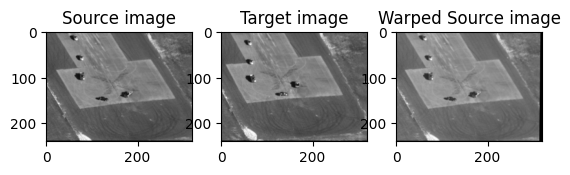

In [16]:
import cv2

num_iters = 100
threshold = 0.01
seq = np.load("aerialseq.npy")
It = seq[:,:,0]
It1 = seq[:,:,10]

# Source frame
plt.figure()
plt.subplot(1,3,1)
plt.imshow(It, cmap='gray')
plt.title('Source image')

# Target frame
plt.subplot(1,3,2)
plt.imshow(It1, cmap='gray')
plt.title('Target image')

# Warped source frame
M = InverseCompositionAffine(It, It1, threshold, num_iters)
warped_It = cv2.warpAffine(It, M,(It.shape[1],It.shape[0]))
plt.subplot(1,3,3)
plt.imshow(warped_It, cmap='gray')
plt.title('Warped Source image')

## Q4.2 Tracking with Inverse Composition (10 points)

Re-use your impplementation in Q3.2 for subtract dominant motion. Just make sure to use InverseCompositionAffine within.

In [29]:
import numpy as np
from scipy.ndimage import binary_erosion
from scipy.ndimage import binary_dilation
from scipy.ndimage import affine_transform
import scipy.ndimage
import cv2

def SubtractDominantMotion(It, It1, num_iters, threshold, tolerance):
    """
    :param It        : (H, W), current image
    :param It1       : (H, W), next image
    :param num_iters : (int), number of iterations for running the optimization
    :param threshold : (float), if the length of dp < threshold, terminate the optimization
    :param tolerance : (float), binary threshold of intensity difference when computing the mask
    :return: mask    : (H, W), the mask of the moved object
    """
    mask = np.ones(It.shape, dtype=bool)

    # ===== your code here! =====
    M = InverseCompositionAffine(It, It1, threshold, num_iters)
    rows, cols = It.shape
    # Warp It using M so that is it registered with It1
    warped_It = cv2.warpAffine(It, M, (cols, rows))
    # Compute the difference between It1 and the warped It
    diff = np.abs(It1 - warped_It)
    # Create a mask of the moved object
    mask = diff > tolerance
    # Binary erosion to remove noise pixels
    mask = binary_erosion(mask)
    # Binary dilation to fill in holes
    mask = binary_dilation(mask)
    # ===== End of code =====

    return mask


Re-use your implementation in Q3.3 for sequence tracking.

In [30]:
from tqdm import tqdm

def TrackSequenceAffineMotion(seq, num_iters, threshold, tolerance):
    """
    :param seq       : (H, W, T), sequence of frames
    :param num_iters : int, number of iterations for running the optimization
    :param threshold : float, if the length of dp < threshold, terminate the optimization
    :param tolerance : (float), binary threshold of intensity difference when computing the mask
    :return: masks   : (T, 4) moved objects for each frame
    """
    H, W, N = seq.shape

    masks =[]
    It = seq[:,:,0]

    # ===== your code here! =====
    for i in tqdm(range(1, seq.shape[2])):
        It1 = seq[:,:,i]
        mask = SubtractDominantMotion(It, It1, num_iters, threshold, tolerance)

        masks.append(mask)
        It = It1

    # ===== End of code =====
    masks = np.stack(masks, axis=2)
    return masks

Track the ant sequence with inverse composition method.


In [19]:
seq = np.load("antseq.npy")

# NOTE: feel free to play with these parameters
num_iters = 1000
threshold = 0.01
tolerance = 0.2

tic = time.time()
masks = TrackSequenceAffineMotion(seq, num_iters, threshold, tolerance)
toc = time.time()
print('\nAnt Sequence takes %f seconds' % (toc - tic))

100%|██████████| 124/124 [00:17<00:00,  7.10it/s]


Ant Sequence takes 17.542550 seconds


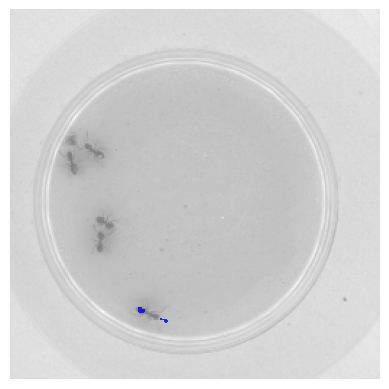

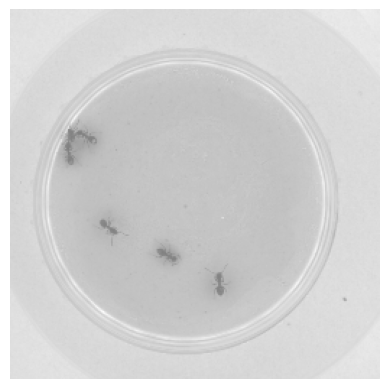

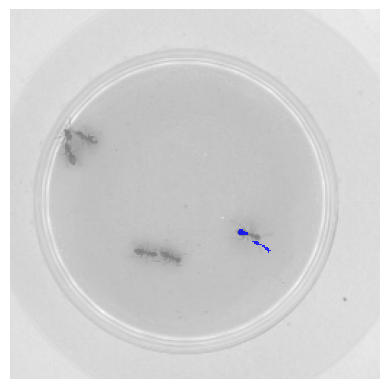

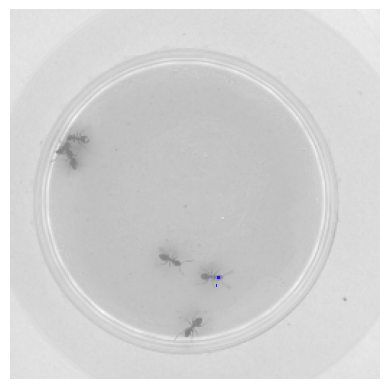

In [20]:
frames_to_save = [29, 59, 89, 119]

# TODO: visualize
for idx in frames_to_save:
    frame = seq[:, :, idx]
    mask = masks[:, :, idx]

    plt.figure()
    plt.imshow(frame, cmap="gray", alpha=0.5)
    plt.imshow(np.ma.masked_where(np.invert(mask), mask), cmap='winter', alpha=0.8)
    plt.axis('off')


Track the aerial sequence with inverse composition method.


In [32]:
seq = np.load("aerialseq.npy")

# NOTE: feel free to play with these parameters
num_iters = 1000
threshold = 0.01
tolerance = 0.2

tic = time.time()
masks = TrackSequenceAffineMotion(seq, num_iters, threshold, tolerance)
toc = time.time()
print('\nAerial Sequence takes %f seconds' % (toc - tic))

100%|██████████| 149/149 [00:49<00:00,  2.99it/s]


Aerial Sequence takes 49.850048 seconds


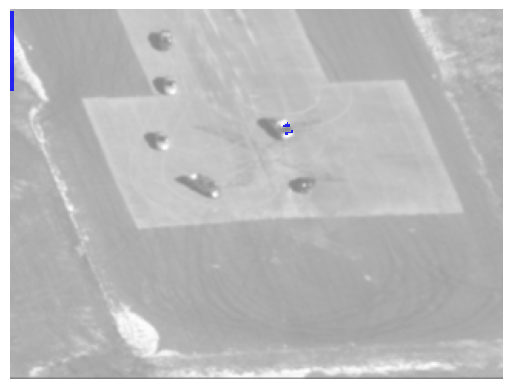

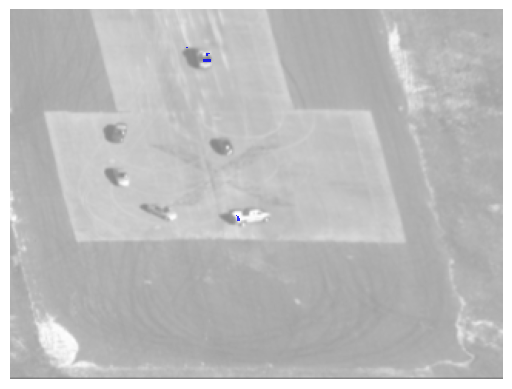

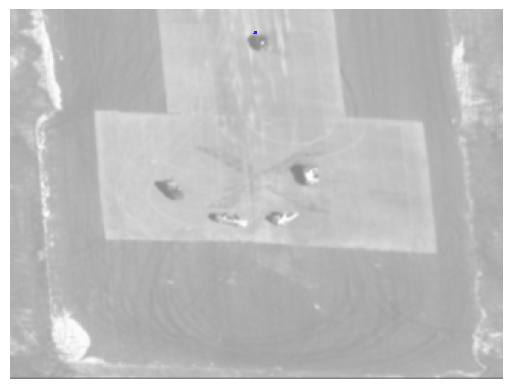

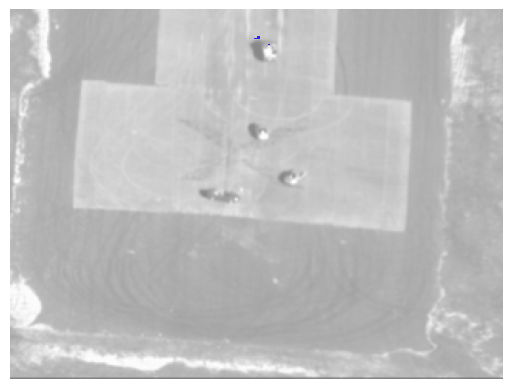

In [22]:
frames_to_save = [29, 59, 89, 119]

# TODO: visualize
for idx in frames_to_save:
    frame = seq[:, :, idx]
    mask = masks[:, :, idx]

    plt.figure()
    plt.imshow(frame, cmap="gray", alpha=0.5)
    plt.imshow(np.ma.masked_where(np.invert(mask), mask), cmap='winter', alpha=0.8)
    plt.axis('off')

## Q4.2.1 Compare the runtime of the algorithm using inverse composition (as described in this section) with its runtime without inverse composition (as detailed in the previous section) in the context of the ant and aerial sequences:
===== your answer here! =====
| Dataset | Inverse Composition | Affine | 
| ------- | ------------------- | ------ |
| Ant     | 17.54s              | 20.03s |
| Aerial  | 47.85s              | 69.01s |

===== end of your answer ====

## Q4.2.2 In your own words, please describe briefly why the inverse compositional approach is more computationally efficient than the classical approach:
===== your answer here! =====
The inverse compositional approach is more computationally efficient because pre-competes the steepest descent images (gradient * jacobian) once at the beginning as opposed to recomputing it every iteration.

===== end of your answer ====